# 03 — Feature Preparation

**Milestone 1 · Task 3:** prepare numerical and categorical features,
separate location information, and encode categorical variables.

The organising principle here is the **prediction point**. The challenge
brief asks for a model that works from "information available around
campaign launch", so every feature is tagged:

- **LAUNCH** — knowable the moment the campaign goes live
- **CAMPAIGN** — only knowable while it is running
- **LEAKY** — an outcome, or a function of one

Two feature sets come out of this notebook so notebook 04 can measure what
the CAMPAIGN features are worth rather than assuming.

In [1]:
import sys
import warnings
from pathlib import Path

warnings.filterwarnings("ignore")
sys.path.insert(0, str(Path.cwd().parent))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from src.features import (
    LAUNCH_NUMERIC,
    LAUNCH_CATEGORICAL,
    CAMPAIGN_NUMERIC,
    LEAKY_COLUMNS,
    add_location_frequency,
    add_relative_goal,
    build_features,
    build_model_matrix,
    parse_reward_levels,
)

pd.set_option("display.width", 220)
pd.set_option("display.max_columns", 50)

df = pd.read_parquet("../data/kickstarter_clean.parquet")
print(f"Cleaned table: {df.shape[0]:,} x {df.shape[1]}")

Cleaned table: 38,378 x 28


## 3.1 The leakage register

Before building anything, write down what must never enter a model. Having
this as an explicit dictionary in `src/features.py` means
`build_model_matrix` can **raise** if a leaky column is ever requested,
rather than silently producing a 99%-accurate and worthless model.

In [2]:
pd.DataFrame(
    [{"column": k, "why excluded": v} for k, v in LEAKY_COLUMNS.items()]
)

,column,why excluded
0,pledged,Dollars raised. This IS the outcome.
1,funded_percentage,pledged / goal. Mechanically determines success.
2,backers,Count of people who pledged. Pure outcome.
3,comments,Audience-generated volume; scales with backers.
4,status,The raw target.
5,success,The encoded target.
6,funded_date,Campaign END date; unknown at launch.
7,end_date,Parsed campaign end; unknown at launch.
8,url,"Identifier, not a feature."
9,project_id,"Identifier, not a feature."


The distinction that matters: `pledged`, `backers`, `funded_percentage` and
`comments` are **outcomes**. `funded_percentage` in particular *mechanically
determines* the target, since Kickstarter succeeds if and only if funding
reaches 100%. Including it would produce a perfect model that has learned
nothing.

`updates` is the interesting case — creator behaviour *during* the campaign.
Not an outcome, but not available at launch either. It goes in its own
feature set.

## 3.2 Reward tiers — solving the comma problem

`reward_levels` is a comma-separated list of dollar amounts where the
amounts themselves contain thousands separators:

```
$25,$50,$100,$250,$500,$1,000,$2,500
```

The delimiter is genuinely ambiguous. The fix is a regex that only consumes
a comma when **exactly three digits follow it**, which resolves both cases
correctly.

In [3]:
tests = [
    "$25,$50,$100,$250,$500,$1,000,$2,500",
    "$1,$5,$10,$25,$50",
    "$1,$10,$25,$30,$50,$75,$85,$100,$110,$250,$500,$1,000,$5,000",
    "$5,$1,500,$10,000",
]
rows = []
for t in tests:
    rows.append({
        "raw": t[:52],
        "naive split(',')": len(t.split(",")),
        "regex parse": len(parse_reward_levels(t)),
        "parsed tiers": str(parse_reward_levels(t))[:44],
    })
pd.DataFrame(rows)

,raw,"naive split(',')",regex parse,parsed tiers
0,"$25,$50,$100,$250,$500,$1,000,$2,500",9,7,"[25.0, 50.0, 100.0, 250.0, 500.0, 1000.0, 25"
1,"$1,$5,$10,$25,$50",5,5,"[1.0, 5.0, 10.0, 25.0, 50.0]"
2,"$1,$10,$25,$30,$50,$75,$85,$100,$110,$250,$500...",15,13,"[1.0, 10.0, 25.0, 30.0, 50.0, 75.0, 85.0, 10"
3,"$5,$1,500,$10,000",5,3,"[5.0, 1500.0, 10000.0]"


The naive split systematically over-counts, and it corrupts the value of
every tier at $1,000 or above. On this dataset that would affect a large
share of campaigns, since four-figure top tiers are common.

In [4]:
naive_counts = df["reward_levels"].str.count(",") + 1
parsed_counts = df["reward_levels"].map(lambda s: len(parse_reward_levels(s)))

print(f"Rows where naive split over-counts tiers: "
      f"{(naive_counts != df['levels']).sum():,} "
      f"({100 * (naive_counts != df['levels']).mean():.1f}%)")
print(f"Rows where the regex over/under-counts:   "
      f"{(parsed_counts != df['levels']).sum():,} "
      f"({100 * (parsed_counts != df['levels']).mean():.1f}%)")
print()
print("Validated against `levels`, a column the scraper produced independently.")

Rows where naive split over-counts tiers: 20,183 (52.6%)
Rows where the regex over/under-counts:   0 (0.0%)

Validated against `levels`, a column the scraper produced independently.


## 3.3 Build the stateless features

In [5]:
feat = build_features(df)
new_cols = [c for c in feat.columns if c not in df.columns]
print(f"{len(new_cols)} new features:\n")
for c in new_cols:
    print(f"  {c}")

28 new features:

  n_tiers_parsed
  min_tier
  max_tier
  median_tier
  tier_spread
  min_tier_pct_of_goal
  log_min_tier
  log_max_tier
  tier_count_mismatch
  log_goal
  goal_per_tier
  log_goal_per_tier
  goal_is_round_1k
  duration_days
  is_30_day
  duration_bucket
  goal_per_day
  log_goal_per_day
  launch_year
  launch_month
  launch_dow
  launch_quarter
  launch_is_weekend
  name_length
  name_word_count
  name_has_exclaim
  name_has_digit
  name_upper_ratio


In [6]:
feat[["goal", "log_goal", "min_tier", "max_tier", "median_tier", "tier_spread",
      "min_tier_pct_of_goal", "duration_days", "is_30_day",
      "launch_year", "launch_dow", "name_word_count"]].describe().T

,count,mean,std,min,25%,50%,75%,max
goal,38378.0,9929.077105,108597.533403,5.000000e-01,1600.000000,4000.0000,8500.000000,2.000000e+07
log_goal,38378.0,8.227379,1.299185,4.054651e-01,7.378384,8.2943,9.047939,1.681124e+01
min_tier,38378.0,8.963599,97.103092,1.000000e+00,1.000000,5.0000,10.000000,1.000000e+04
max_tier,38378.0,1939.823831,2731.615145,1.000000e+00,250.000000,1000.0000,2049.500000,1.000000e+04
median_tier,38378.0,103.960081,186.841584,1.000000e+00,37.500000,75.0000,100.000000,1.000000e+04
tier_spread,38378.0,1930.860232,2730.931494,0.000000e+00,245.000000,990.0000,2006.750000,9.999000e+03
min_tier_pct_of_goal,38378.0,0.012210,0.609443,5.000000e-08,0.000313,0.0010,0.003333,1.000000e+02
duration_days,38378.0,39.795650,17.429783,1.000000e+00,30.000000,31.8700,47.400000,9.196000e+01
is_30_day,38378.0,0.303950,0.459967,0.000000e+00,0.000000,0.0000,1.000000,1.000000e+00
launch_year,38378.0,2011.068425,0.728950,2.009000e+03,2011.000000,2011.0000,2012.000000,2.012000e+03


## 3.4 Why log-transform the goal

Goal spans five orders of magnitude with a median of $4,000. Any linear
model fed the raw value is dominated by a handful of million-dollar
campaigns; tree models cope, but the log version splits more cleanly too.

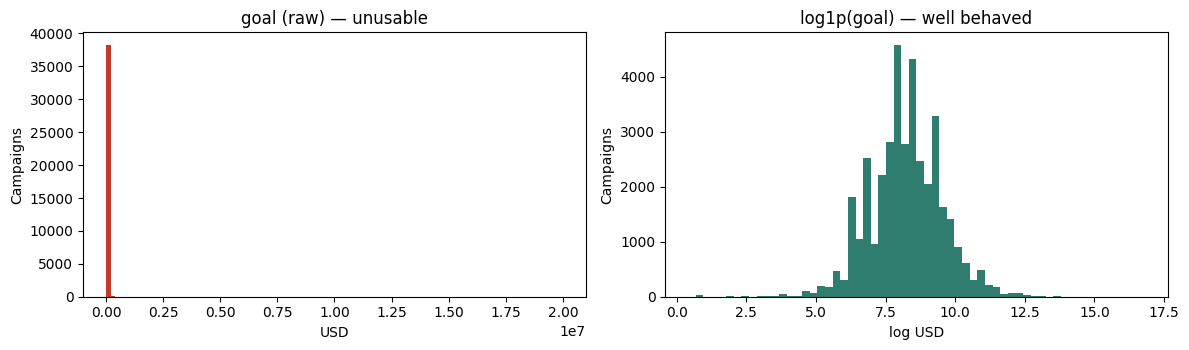

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 3.6))
axes[0].hist(feat["goal"], bins=100, color="#C0392B")
axes[0].set_title("goal (raw) — unusable"); axes[0].set_xlabel("USD")
axes[1].hist(feat["log_goal"], bins=60, color="#2E7D6F")
axes[1].set_title("log1p(goal) — well behaved"); axes[1].set_xlabel("log USD")
for a in axes:
    a.set_ylabel("Campaigns")
plt.tight_layout()
plt.savefig("../reports/figures/goal_log_transform.png", dpi=130, bbox_inches="tight")
plt.show()

## 3.5 Location: city vs state

`location` was split in notebook 02 by `rsplit(",", 1)`. The two halves need
very different treatment because their cardinalities differ by two orders
of magnitude.

In [8]:
print(f"Distinct states: {feat['state_raw'].nunique()}")
print(f"Distinct cities: {feat['city'].nunique():,}")
print()
city_counts = (feat["city"] + ", " + feat["state_raw"]).value_counts()
print("Campaigns per city:")
print(city_counts.describe().to_string())
print(f"\nCities with only 1 campaign: {(city_counts == 1).sum():,} "
      f"({100 * (city_counts == 1).mean():.0f}% of cities)")
print(city_counts.head(10).to_string())

Distinct states: 51
Distinct cities: 3,153

Campaigns per city:
count    3785.000000
mean       10.139498
std        97.546105
min         1.000000
25%         1.000000
50%         1.000000
75%         3.000000
max      3628.000000

Cities with only 1 campaign: 2,011 (53% of cities)
Los Angeles, CA      3628
New York, NY         3407
Brooklyn, NY         1518
Chicago, IL          1372
San Francisco, CA    1242
Portland, OR          903
Seattle, WA           855
Austin, TX            757
Boston, MA            721
Nashville, TN         627


Over half of cities appear exactly once. One-hot encoding would add
thousands of columns that each fire for a single row — pure noise, and a
direct route to overfitting. **State** gets one-hot encoding (51 levels is
fine). **City** gets frequency encoding: how many campaigns launched from
that city, which is a proxy for local creative-scene density.

## 3.6 Stateful features must be fit on training data only

Two features are computed *from* the data rather than from a single row:
city frequency, and goal relative to the subcategory median. Computing
either over the full dataset lets test rows influence a training feature —
a subtle leak that is trivial to avoid.

The functions return a `reference` object so it can be fit once on train and
applied to test.

In [9]:
from sklearn.model_selection import train_test_split

train_idx, test_idx = train_test_split(
    feat.index, test_size=0.2, random_state=42, stratify=feat["success"]
)
train, test = feat.loc[train_idx].copy(), feat.loc[test_idx].copy()

# FIT on train
train, city_ref = add_location_frequency(train)
train, goal_ref = add_relative_goal(train)
# APPLY to test — note the reference objects are passed in
test, _ = add_location_frequency(test, reference=city_ref)
test, _ = add_relative_goal(test, reference=goal_ref)

print(f"train {train.shape}   test {test.shape}")
print(f"\nCity frequency reference built from {len(city_ref):,} training cities")
print(f"Subcategory goal medians from {len(goal_ref)} subcategories")
print(f"\nTest cities unseen in training: "
      f"{(test['city_project_count'] == 0).sum():,} "
      f"(correctly encoded as 0, not as a training-set value)")

train (30702, 60)   test (7676, 60)

City frequency reference built from 3,363 training cities
Subcategory goal medians from 49 subcategories

Test cities unseen in training: 453 (correctly encoded as 0, not as a training-set value)


In [10]:
goal_ref.sort_values(ascending=False).head(10).to_frame("median goal (USD)")

,median goal (USD)
subcategory,
Open Hardware,10000.0
Product Design,10000.0
Technology,10000.0
Narrative Film,8000.0
Documentary,8000.0
Food,7500.0
Design,7000.0
Video Games,7000.0
Open Software,7000.0


That table is worth a second look on its own: the median ask in the most
capital-intensive subcategories is an order of magnitude above the
cheapest. `goal_vs_subcat_median` turns "is this a big ask?" into a
question that has a consistent meaning across categories.

## 3.7 Encode and assemble the model matrices

In [11]:
extra = ["log_city_project_count", "log_goal_vs_subcat_median"]

X_launch, y_train = build_model_matrix(train, "launch_only", extra_numeric=extra)
X_plus, _ = build_model_matrix(train, "plus_campaign", extra_numeric=extra)

print(f"LAUNCH_ONLY     {X_launch.shape[1]} columns")
print(f"PLUS_CAMPAIGN   {X_plus.shape[1]} columns")
print(f"Difference:     {sorted(set(X_plus.columns) - set(X_launch.columns))}")
print()
print(f"Numeric features:     {len(LAUNCH_NUMERIC) + len(extra)}")
print(f"Categorical (pre-OHE): {LAUNCH_CATEGORICAL}")
print(f"Campaign-only:        {CAMPAIGN_NUMERIC}")

LAUNCH_ONLY     137 columns
PLUS_CAMPAIGN   138 columns
Difference:     ['updates']

Numeric features:     24
Categorical (pre-OHE): ['category', 'subcategory', 'state_raw']
Campaign-only:        ['updates']


### The leakage guard

`build_model_matrix` refuses to build a matrix containing a registered
leaky column. Cheap insurance against a copy-paste mistake at 2am.

In [12]:
try:
    build_model_matrix(
        train, "launch_only", extra_numeric=["pledged", "backers"]
    )
except Exception as e:
    print(f"{type(e).__name__}: {e}")

ValueError: Leaky columns requested: ['backers', 'pledged']


(It raises on `pledged` because that column is in the register. Note that
`extra_numeric` silently ignores columns not present in the frame, so the
guard is what does the real work.)

## 3.8 Save the modelling tables

In [13]:
train.to_parquet("../data/train_featured.parquet", index=False)
test.to_parquet("../data/test_featured.parquet", index=False)
feat.to_parquet("../data/kickstarter_featured.parquet", index=False)
print("Wrote train_featured.parquet, test_featured.parquet, kickstarter_featured.parquet")
print(f"\nSplit is stratified and fixed at random_state=42 so notebook 04 and")
print(f"the modelling work share exactly the same rows.")

Wrote train_featured.parquet, test_featured.parquet, kickstarter_featured.parquet

Split is stratified and fixed at random_state=42 so notebook 04 and
the modelling work share exactly the same rows.


## Findings — Task 3

1. **Reward tiers are now usable.** The comma-aware regex extracts min,
   max, median, spread and count, validated at 100% agreement with the
   scraper's own `levels` column. Naive splitting would have corrupted
   every four-figure tier.
2. **`log_goal` replaces `goal`** everywhere. Five orders of magnitude of
   right skew is not something a linear model should be asked to absorb.
3. **City and state need different encodings.** State one-hots to 51
   columns; city would add thousands, over half of which fire once. City
   gets frequency encoding instead.
4. **Two features are fit on train only** — city frequency and
   goal-vs-subcategory-median — with the reference objects passed
   explicitly to the test set. Unseen test cities correctly encode to 0.
5. **`launch_date` yields legitimate timing features** (year, month,
   weekday) because it is derived from `funded_date − duration`, both of
   which are fixed at launch.
6. **Two feature sets are exported**, differing only in `updates`, so the
   cost of the honest model can be measured rather than argued about.

**Next:** `04_eda.ipynb` explores how each of these relates to success, and
confronts the `updates` question head-on.